#Retrieval:

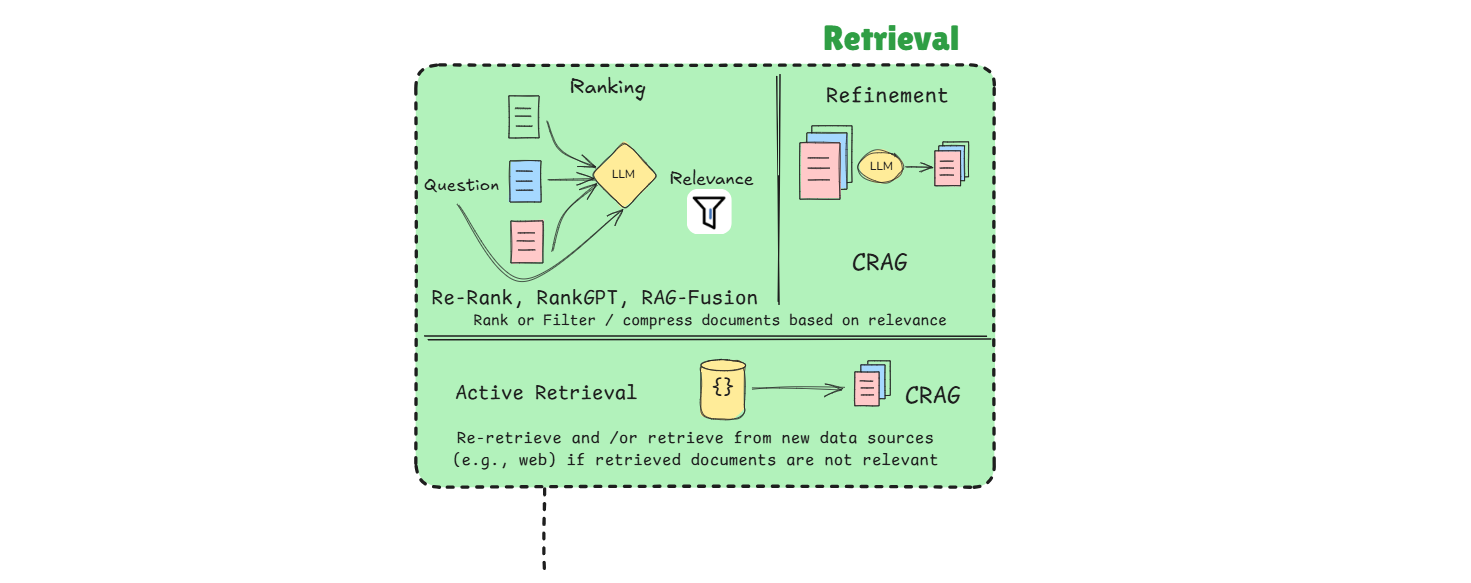

In [ ]:
from IPython.display import Image
display(Image("/content/Screenshot 2025-09-12 121056.png"))

# RAG Fusion and RRF Explained

## RAG Fusion (Retrieval-Augmented Generation Fusion)

**RAG Fusion** is an advanced RAG technique that improves retrieval quality by generating multiple search queries and combining their results.

### How it works:

1. **Query Expansion**: Takes your original query and uses an LLM to generate multiple related queries (usually 3-5 variations)
   - Original: "What is task decomposition?"
   - Generated queries:
     - "How do you break down complex tasks?"
     - "What are methods for decomposing tasks into subtasks?"
     - "Explain task breakdown strategies"

2. **Parallel Retrieval**: Searches the vector database with all generated queries simultaneously

3. **Result Fusion**: Combines and re-ranks all retrieved documents using **RRF** (Reciprocal Rank Fusion)

4. **Deduplication**: Removes duplicate documents

5. **Final Output**: Returns the best-ranked unique documents

### Benefits:
- **Better coverage**: Captures different aspects of the user's intent
- **More robust**: Less sensitive to query phrasing
- **Higher quality results**: Reduces the chance of missing relevant information

---

## RRF (Reciprocal Rank Fusion)

**RRF** is a ranking algorithm that combines results from multiple ranked lists without needing relevance scores.

### The Formula:

For each document, the RRF score is calculated as:

$$\text{RRF}(d) = \sum_{r \in R} \frac{1}{k + \text{rank}_r(d)}$$

Where:
- $d$ = document
- $R$ = set of all ranked lists (from different queries)
- $\text{rank}_r(d)$ = position of document $d$ in ranking $r$
- $k$ = constant (typically 60) to prevent division by zero and reduce the impact of high rankings

### Example:

Let's say we have 3 queries and retrieve documents A, B, C, D:

**Query 1 results:** A (rank 1), B (rank 2), C (rank 3)
**Query 2 results:** B (rank 1), D (rank 2), A (rank 3)
**Query 3 results:** A (rank 1), C (rank 2), B (rank 4)

Using k=60:

**Document A:**
- RRF = 1/(60+1) + 1/(60+3) + 1/(60+1) = 1/61 + 1/63 + 1/61 ≈ **0.0485**

**Document B:**
- RRF = 1/(60+2) + 1/(60+1) + 1/(60+4) = 1/62 + 1/61 + 1/64 ≈ **0.0475**

**Document C:**
- RRF = 1/(60+3) + 1/(60+2) = 1/63 + 1/62 ≈ **0.0317**

**Document D:**
- RRF = 1/(60+2) = 1/62 ≈ **0.0161**

**Final ranking:** A > B > C > D

### Why RRF is great:

✅ **No score normalization needed**: Works with just rankings, not scores
✅ **Simple and effective**: Easy to implement and understand
✅ **Democratic**: Documents appearing in multiple lists get boosted
✅ **Robust**: Not sensitive to outlier scores from one retriever


##Enviornment
(1) Packages

In [ ]:
%%capture
! pip install langchain_community tiktoken langchain_groq langchainhub chromadb langchain-cohere

## Tracing:

Optionally, use LangSmith for tracing (shown at bottom) by setting:

In [ ]:
from google.colab import userdata
import os

os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ["LANGCHAIN_PROJECT"] ="Retrieval Mechanisms"

##Part 1: Re-Ranking
We have learnt this previously with RAG-fusion.<br>
flow:

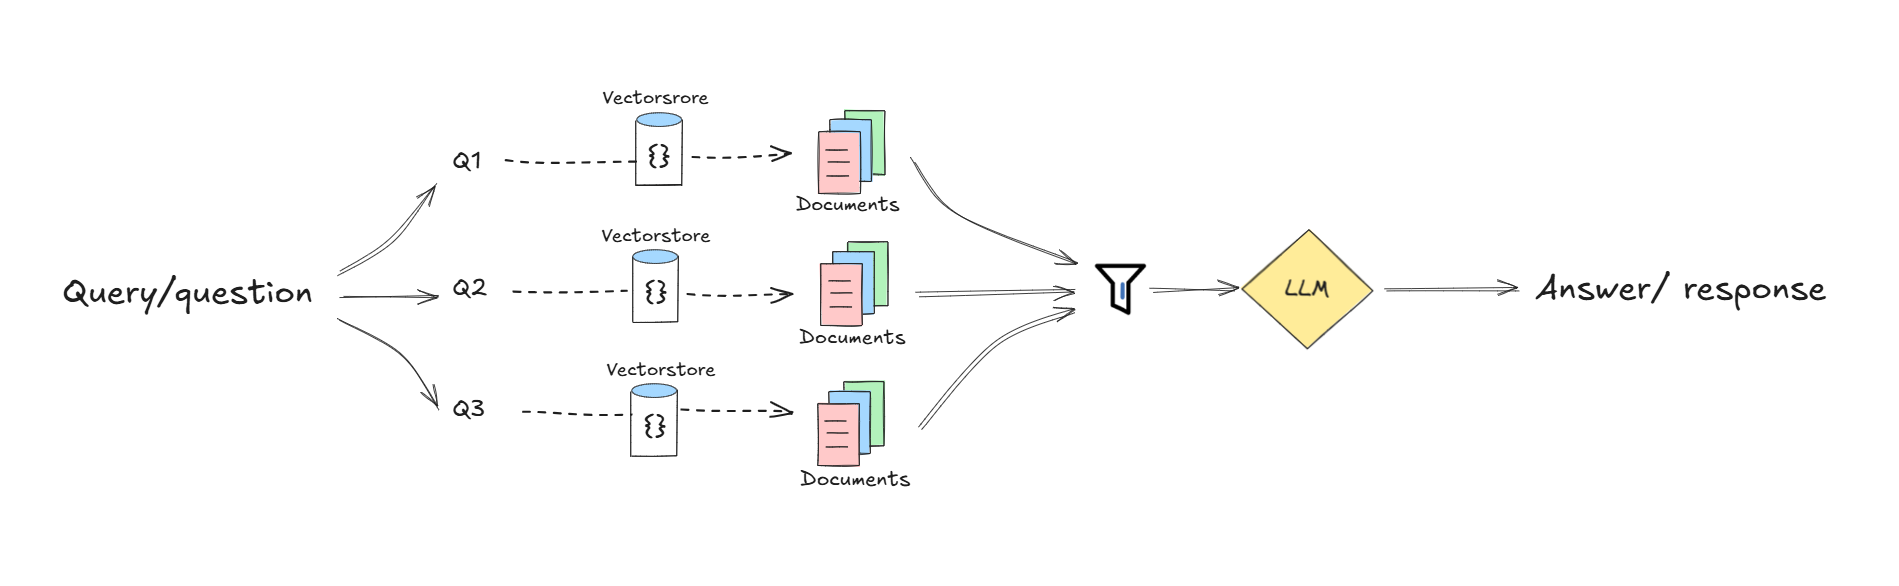

In [ ]:
display(Image("/content/Screenshot 2025-09-04 101824.png"))

In [ ]:
# Imports
import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.embeddings import SentenceTransformerEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate

from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from google.colab import userdata
from langchain_core.load import dumps, loads

In [ ]:
#### INDEXING ####

# Load blog
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()


# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300,
    chunk_overlap=50)


# Make splits
splits = text_splitter.split_documents(blog_docs)


# Index
# from langchain_cohere import CohereEmbeddings
from langchain_community.vectorstores import Chroma
vectorstore = Chroma.from_documents(documents=splits,
                                    # embedding=CohereEmbeddings()
                                    embedding=SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2"))



retriever = vectorstore.as_retriever()

/tmp/ipython-input-3845174307.py:30: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding=SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2"))
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  war

In [ ]:
### RAG-Fusion ###
template = """You are a helpful assistant that generates multiple search queries based on a single input query. \n
Generate multiple search queries related to: {question} \n
Output (4 queries):"""
prompt_rag_fusion = ChatPromptTemplate.from_template(template)

In [ ]:
### LLM (Groq)###
llm = ChatGroq(
    groq_api_key=userdata.get('GROQ_API_KEY'),  # Use userdata.get to retrieve the key
    model="meta-llama/llama-4-scout-17b-16e-instruct", # you can switch to other Groq-supported models
    temperature=0
)

generate_queries = (
    prompt_rag_fusion
    | llm
    | StrOutputParser()
    | (lambda x: x.split("\n"))
)

In [ ]:
# RRF (reciprocal rank fusion)
def reciprocal_rank_fusion(results: list[list], k=60):
    """ Reciprocal_rank_fusion that takes multiple lists of ranked documents
        and an optional parameter k used in the RRF formula """

    # Initialize a dictionary to hold fused scores for each unique document
    fused_scores = {}

    # Iterate through each list of ranked documents
    for docs in results:
        # Iterate through each document in the list, with its rank (position in the list)
        for rank, doc in enumerate(docs):
            # Convert the document to a string format to use as a key (assumes documents can be serialized to JSON)
            doc_str = dumps(doc)
            # If the document is not yet in the fused_scores dictionary, add it with an initial score of 0
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0
            # Retrieve the current score of the document, if any
            previous_score = fused_scores[doc_str]
            # Update the score of the document using the RRF formula: 1 / (rank + k)
            fused_scores[doc_str] += 1 / (rank + k)

    # Sort the documents based on their fused scores in descending order to get the final reranked results
    reranked_results = [
        (loads(doc), score)
        for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]

    # Return the reranked results as a list of tuples, each containing the document and its fused score
    return reranked_results

question = "What is task decomposition for LLM agents?"

retrieval_chain_rag_fusion = generate_queries | retriever.map() | reciprocal_rank_fusion
docs = retrieval_chain_rag_fusion.invoke({"question": question})

len(docs)

/tmp/ipython-input-3996748566.py:25: LangChainBetaWarning: The function `loads` is in beta. It is actively being worked on, so the API may change.
  (loads(doc), score)


10

In [ ]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough

# RAG
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    {"context": retrieval_chain_rag_fusion,
     "question": itemgetter("question")}
    | prompt
    | llm
    | StrOutputParser()
    | (lambda x: print(x))
)

final_rag_chain.invoke({"question":question})

Task decomposition for LLM (Large Language Model) agents refers to the process of breaking down complex tasks into smaller, manageable subgoals or steps. This technique is essential for enhancing the performance of LLMs on complicated tasks.

There are several methods for task decomposition:

1. **Chain of Thought (CoT)**: This involves instructing the model to "think step by step" to utilize more test-time computation to decompose hard tasks into smaller and simpler steps.
2. **Tree of Thoughts**: This approach extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure.
3. **LLM with simple prompting**: Task decomposition can be done using simple prompts like "Steps for XYZ.\n1.", "What are the subgoals for achieving XYZ?"
4. **Task-specific instructions**: Task decomposition can also be done using task-specific instructions, such as "Write a sto


We can also use [Cohere Re-Rank](https://python.langchain.com/docs/integrations/retrievers/cohere-reranker/#doing-reranking-with-coherererank).

See [here](https://cohere.com/blog/rerank):

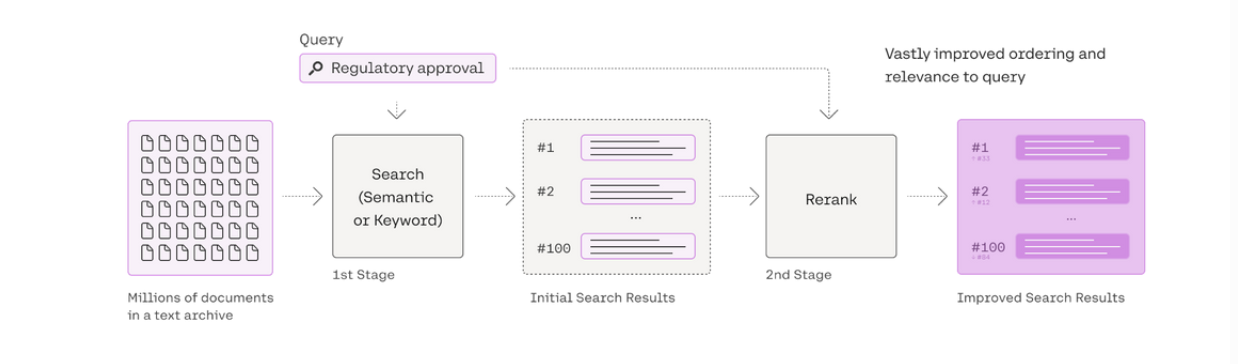

In [ ]:
from IPython.display import Image
display(Image("/content/Screenshot 2025-11-01 105716.png"))

In [ ]:
pip show langchain langchain-cohere langchain-community

Name: langchain
Version: 0.3.27
Summary: Building applications with LLMs through composability
Home-page: 
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langchain-text-splitters, langsmith, pydantic, PyYAML, requests, SQLAlchemy
Required-by: langchain-community
---
Name: langchain-cohere
Version: 0.4.6
Summary: An integration package connecting Cohere and LangChain
Home-page: https://github.com/langchain-ai/langchain-cohere
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: cohere, langchain-community, langchain-core, pydantic, types-pyyaml
Required-by: 
---
Name: langchain-community
Version: 0.3.31
Summary: Community contributed LangChain integrations.
Home-page: 
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: aiohttp, dataclasses-json, httpx-sse, langchain, langchain-core, langsmith, numpy, pydantic-settings, PyYAML, reques

In [ ]:
from langchain_cohere import CohereRerank
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever

# Your code
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

# Re-rank
compressor = CohereRerank(
    cohere_api_key=userdata.get('COHERE_API_KEY'),
    model="rerank-english-v3.0"
)

compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=retriever
)

# Example query
query = "What is task decomposition?"

# Retrieve and re-rank documents
compressed_docs = compression_retriever.invoke(query)

# Display the re-ranked documents
print(f"Retrieved and re-ranked documents for the query: '{query}'")
for i, doc in enumerate(compressed_docs):
    print(f"\nDocument {i+1}:")
    print(f"Content: {doc.page_content[:300]}...")
    print(f"Score: {doc.metadata.get('relevance_score')}")

Retrieved and re-ranked documents for the query: 'What is task decomposition?'

Document 1:
Content: Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructe...
Score: 0.9989759

Document 2:
Content: Finite context length: The restricted context capacity limits the inclusion of historical information, detailed instructions, API call context, and responses. The design of the system has to work with this limited communication bandwidth, while mechanisms like self-reflection to learn from past mist...
Score: 0.29047745

Document 3:
Content: LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


Building agents with LLM (large language model) as its core controller is a cool concept. Severa

Langsmith Traces:<br>
https://smith.langchain.com/public/2636554b-7fa3-4f99-94b3-1026d338c8fe/r<br>
https://smith.langchain.com/public/476ec541-4db5-4972-86a3-7454e6f05336/r


##Part 2: Retrieval (CRAG)
Deep Dive

https://www.youtube.com/watch?v=E2shqsYwxck

Notebooks

https://github.com/langchain-ai/langgraph/blob/main/examples/rag/langgraph_crag.ipynb

https://github.com/langchain-ai/langgraph/blob/main/examples/rag/langgraph_crag_mistral.ipynb

##Part 3: Generation<br>
Retrieval (Self-RAG)
Notebooks

https://github.com/langchain-ai/langgraph/tree/main/examples/rag
